In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS

In [2]:
start_date = "2015-01-01"
end_date = "2026-01-01"

data = yf.download(
    ["HDFCBANK.NS", "KOTAKBANK.NS"],
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)
data

Price        Adj Close                    Close                     High  \
Ticker     HDFCBANK.NS KOTAKBANK.NS HDFCBANK.NS KOTAKBANK.NS HDFCBANK.NS   
Date                                                                       
2015-01-01  217.235336   124.958961  238.012497   125.860001  238.600006   
2015-01-02  220.258652   126.244698  241.324997   127.154999  242.324997   
2015-01-05  218.399017   125.738350  239.287506   126.644997  242.637497   
2015-01-06  214.999222   124.239151  235.562500   125.135002  239.137497   
2015-01-07  215.626709   126.239738  236.250000   127.150002  237.837494   
...                ...          ...         ...          ...         ...   
2025-12-24  997.200012   432.739990  997.200012   432.739990  999.400024   
2025-12-26  992.099976   432.839996  992.099976   432.839996  997.200012   
2025-12-29  991.700012   431.720001  991.700012   431.720001  997.400024   
2025-12-30  990.900024   430.540009  990.900024   430.540009  995.000000   
2025-12-31  991.200012   440.220001  991.200012   440.220001  997.599976   

Price                           Low                     Open               \
Ticker     KOTAKBANK.NS HDFCBANK.NS KOTAKBANK.NS HDFCBANK.NS KOTAKBANK.NS   
Date                                                                        
2015-01-01   126.500000  236.262497   125.110001  237.750000   126.379997   
2015-01-02   127.900002  237.600006   125.830002  237.600006   126.099998   
2015-01-05   127.885002  238.774994   126.199997  242.500000   127.209999   
2015-01-06   126.224998  234.387497   123.355003  238.500000   125.500000   
2015-01-07   130.395004  234.062500   124.750000  234.925003   124.750000   
...                 ...         ...          ...         ...          ...   
2025-12-24   435.640015  993.000000   432.220001  993.000000   433.600006   
2025-12-26   434.720001  987.700012   430.579987  996.000000   432.399994   
2025-12-29   436.359985  987.200012   431.079987  993.099976   434.119995   
2025-12-30   433.000000  982.200012   427.779999  990.200012   431.940002   
2025-12-31   441.079987  987.599976   431.140015  991.000000   431.600006   

Price           Volume               
Ticker     HDFCBANK.NS KOTAKBANK.NS  
Date                                 
2015-01-01     3544940      2509980  
2015-01-02     5900384      6318150  
2015-01-05     4796000      3051150  
2015-01-06     8219680     11345430  
2015-01-07     5746112     17858870  
...                ...          ...  
2025-12-24    13699996      7791790  
2025-12-26     9360853      3691745  
2025-12-29    13545749      4858980  
2025-12-30    33155849     28360690  
2025-12-31    10963454     14284445  

[2716 rows x 12 columns]

In [3]:
adj_close = data["Adj Close"].copy()
adj_close.columns = ["HDFCBANK", "KOTAKBANK"]
adj_close.dropna(axis=1, inplace=True)
adj_close

,HDFCBANK,KOTAKBANK
Date,,
2015-01-01,217.235336,124.958961
2015-01-02,220.258652,126.244698
2015-01-05,218.399017,125.738350
2015-01-06,214.999222,124.239151
2015-01-07,215.626709,126.239738
...,...,...
2025-12-24,997.200012,432.739990
2025-12-26,992.099976,432.839996
2025-12-29,991.700012,431.720001


<Axes: title={'center': 'Stock Price'}, xlabel='Date'>

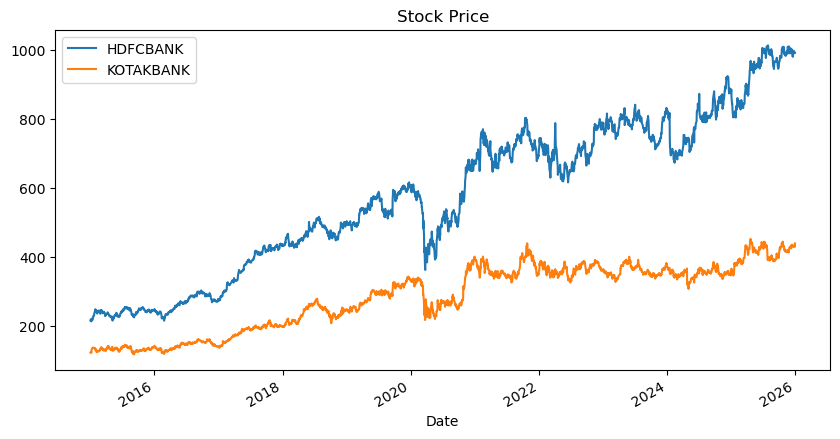

In [4]:
adj_close.plot(figsize=(10,5), title="Stock Price")

In [5]:
log_prices = np.log(adj_close)
log_prices

,HDFCBANK,KOTAKBANK
Date,,
2015-01-01,5.380981,4.827985
2015-01-02,5.394803,4.838222
2015-01-05,5.386324,4.834203
2015-01-06,5.370634,4.822208
2015-01-07,5.373549,4.838183
...,...,...
2025-12-24,6.904951,6.070137
2025-12-26,6.899824,6.070368
2025-12-29,6.899421,6.067777


<Axes: title={'center': 'Log Prices'}, xlabel='Date'>

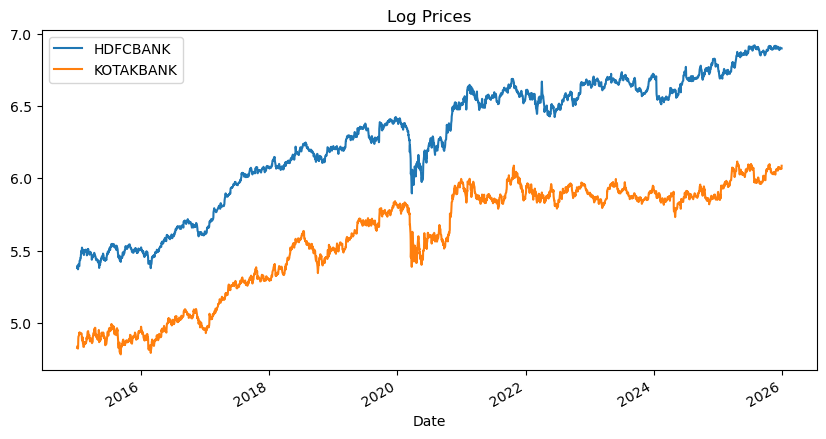

In [6]:
log_prices.plot(figsize=(10,5), title="Log Prices")

### Cointegration (Engle - Granger) Test

In [7]:
coint(log_prices["HDFCBANK"], log_prices["KOTAKBANK"])[1]

0.0005417535099747868

In [8]:
coint(log_prices["KOTAKBANK"], log_prices["HDFCBANK"])[1]

0.0004407544587563347

### Modelling Spread

In [9]:
Y = log_prices["KOTAKBANK"]
X = log_prices["HDFCBANK"]

X = sm.add_constant(X)
model = OLS(Y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              KOTAKBANK   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                 7.499e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:31:04   Log-Likelihood:                 3289.9
No. Observations:                2716   AIC:                            -6576.
Df Residuals:                    2714   BIC:                            -6564.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1638      0.020      8.246      0.000       0.125       0.203
HDFCBANK       0.8647      0.003    273.842      0.000       0.858       0.871
==============================================================================
Omnibus:                       31.067   Durbin-Watson:                   0.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.316
Skew:                           0.219   Prob(JB):                     4.31e-07
Kurtosis:                       2.740   Cond. No.                         92.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
beta = model.params["HDFCBANK"]

spread = log_prices["KOTAKBANK"] - beta * log_prices["HDFCBANK"]
spread

Date
2015-01-01    0.175119
2015-01-02    0.173405
2015-01-05    0.176717
2015-01-06    0.178289
2015-01-07    0.191743
                ...   
2025-12-24    0.099513
2025-12-26    0.104178
2025-12-29    0.101936
2025-12-30    0.099896
2025-12-31    0.121869
Length: 2716, dtype: float64

<Axes: title={'center': 'Spread'}, xlabel='Date'>

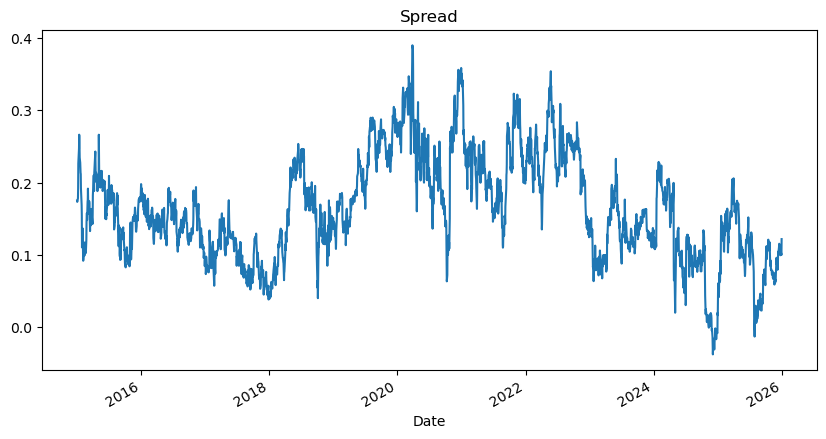

In [11]:
spread.plot(figsize=(10,5), title="Spread")

### Computing Z-Score (using rolling mean and std)

In [12]:
rolling_mean = spread.rolling(60).mean()
rolling_std = spread.rolling(60).std()

z_score = (spread - rolling_mean)/rolling_std
z_score

Date
2015-01-01         NaN
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
                ...   
2025-12-24    0.555121
2025-12-26    0.778509
2025-12-29    0.630748
2025-12-30    0.498908
2025-12-31    1.665828
Length: 2716, dtype: float64

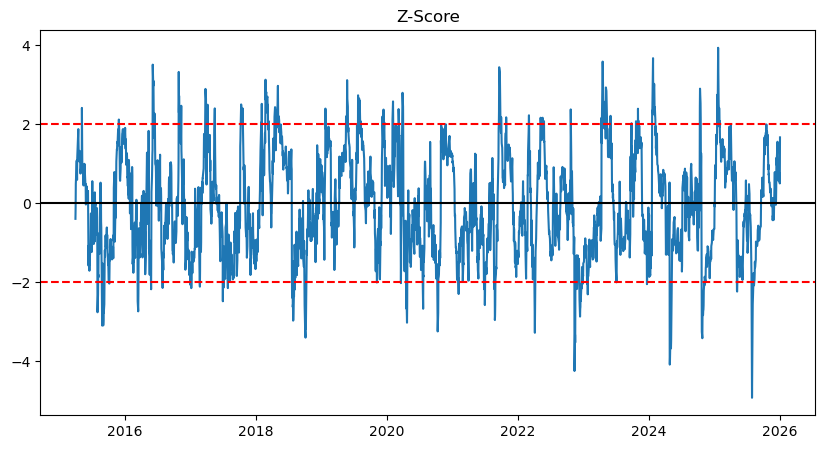

In [13]:
plt.figure(figsize=(10,5))
plt.plot(z_score, label="Z-Score")
plt.axhline(0, color="black")
plt.axhline(-2, color="red", linestyle="--")
plt.axhline(2, color="red", linestyle="--")
plt.title("Z-Score")
plt.show()

### Generating Signals

In [14]:
df = pd.DataFrame({
    "spread": spread,
    "zscore": z_score
})

df.dropna(inplace=True)

df["signal"] = np.nan

df.loc[df["zscore"] > 2, "signal"] = -1
df.loc[df["zscore"] < -2, "signal"] = 1

df.loc[df["zscore"].abs() < 0.5, "signal"] = 0

df["position"] = df["signal"].ffill().fillna(0)

<Axes: xlabel='Date'>

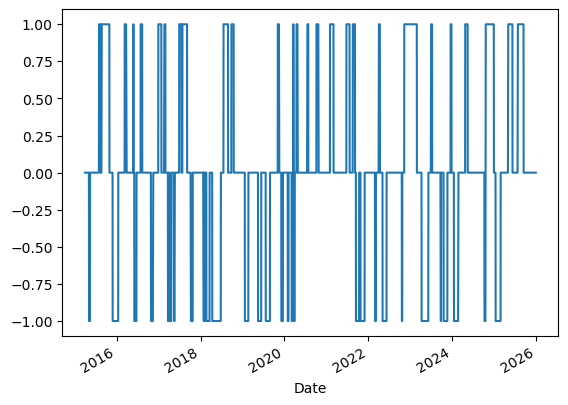

In [15]:
df["position"].plot()

### Computing Returns

In [17]:
df["spread_return"] = df["spread"].diff()

df["strategy_returns"] = df["position"].shift(1) * df["spread_return"]

In [18]:
transac_cost = 0.002

df["trades"] = df["position"].diff().abs()
df["strategy_returns"] -= transac_cost * df["trades"]

In [19]:
df["cum_returns"] = (1 + df["strategy_returns"]).cumprod()
df["cum_returns"]

Date
2015-03-30         NaN
2015-03-31    1.000000
2015-04-01    1.000000
2015-04-06    1.000000
2015-04-07    1.000000
                ...   
2025-12-24    3.875663
2025-12-26    3.875663
2025-12-29    3.875663
2025-12-30    3.875663
2025-12-31    3.875663
Name: cum_returns, Length: 2657, dtype: float64

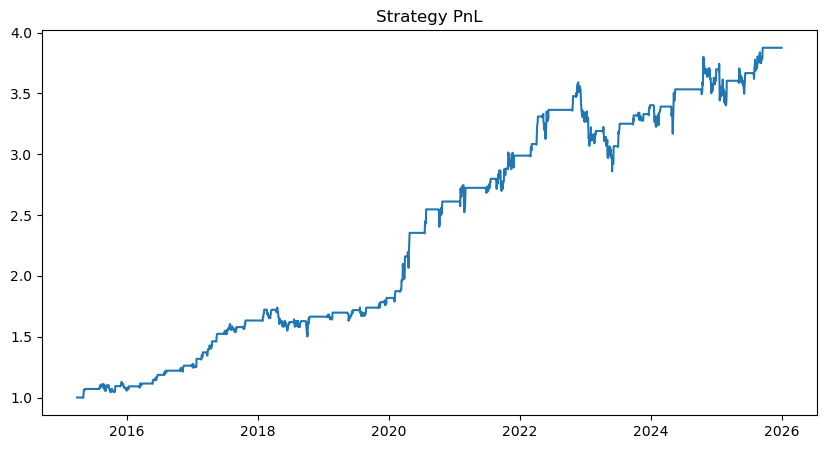

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df["cum_returns"])
plt.title("Strategy PnL")
plt.show()

In [21]:
(df["strategy_returns"].mean() / df["strategy_returns"].std()) * np.sqrt(252)

1.0966867729233127

In [22]:
(df["cum_returns"].cummax() - df["cum_returns"]).max()

0.7320885824892516

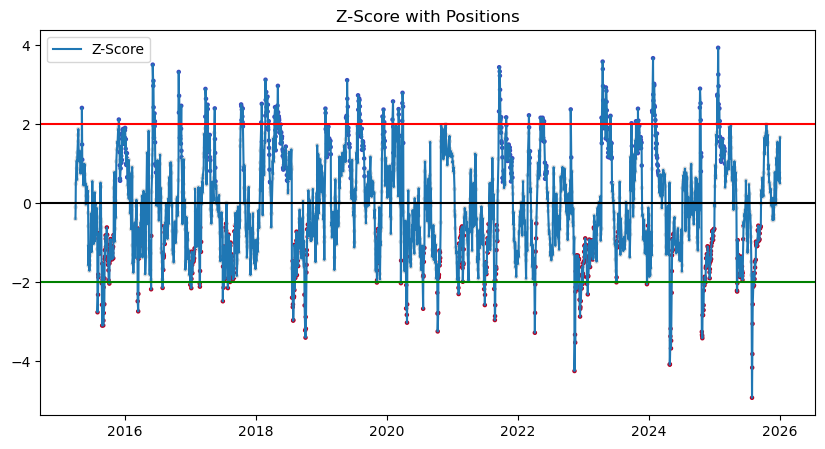

In [24]:
plt.figure(figsize=(10,5))
plt.plot(df["zscore"], label="Z-Score")

plt.axhline(2, color = "red")
plt.axhline(-2, color = "green")
plt.axhline(0, color = "black")

plt.scatter(df.index, df["zscore"], c=df["position"], cmap="coolwarm", s=5)

plt.title("Z-Score with Positions")
plt.legend()
plt.show()